# 🤖 DecodeLabs | AI Project 2: Data Classification Using AI
**Batch: 2026 | Powered by DecodeLabs**

---

## 🎯 Goal
Build a K-Nearest Neighbors (KNN) classification model on the Iris dataset.

## 📋 Pipeline (IPO Framework)
| Stage | Steps |
|-------|-------|
| **INPUT** | Load Iris Dataset → Feature Scaling |
| **PROCESS** | Train-Test Split → KNN Algorithm |
| **OUTPUT** | Confusion Matrix → F1 Score |

---
## 📦 Step 1: Install & Import Libraries

In [ ]:
# ─── Core Data Libraries ───────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Visualization Libraries ──────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Scikit-Learn: Dataset ────────────────────────────────────────
from sklearn.datasets import load_iris

# ─── Scikit-Learn: Preprocessing ─────────────────────────────────
from sklearn.preprocessing import StandardScaler

# ─── Scikit-Learn: Model Selection ───────────────────────────────
from sklearn.model_selection import train_test_split

# ─── Scikit-Learn: Algorithm ──────────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier

# ─── Scikit-Learn: Evaluation Metrics ────────────────────────────
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score
)

# ─── Display Settings ─────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 🌸 Step 2: Load & Explore the Iris Dataset

**The Iris Benchmark:**
- **Samples:** 150 (Balanced — 50 per class)
- **Classes:** 3 (Setosa, Versicolor, Virginica)
- **Features (Dimensions):** 4 (Sepal Length, Sepal Width, Petal Length, Petal Width)

In [19]:
# ─── Load Dataset ─────────────────────────────────────────────────
iris = load_iris()

# Convert to DataFrame for easy exploration
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
df['target']  = iris.target

print('📊 Dataset Shape:', df.shape)
print('🏷️  Classes:', list(iris.target_names))
print('📐 Features:', list(iris.feature_names))
print()
print(df.head(10))

📊 Dataset Shape: (150, 6)
🏷️  Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
📐 Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9         

In [20]:
# ─── Basic Statistics ─────────────────────────────────────────────
print('📈 Statistical Summary:')
df.describe().round(2)

📈 Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20,1.00
std,0.83,0.44,1.77,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


In [21]:
# ─── Check for Missing Values ─────────────────────────────────────
print('🔍 Missing Values:')
print(df.isnull().sum())
print()
print('⚖️  Class Distribution:')
print(df['species'].value_counts())

🔍 Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
target               0
dtype: int64

⚖️  Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


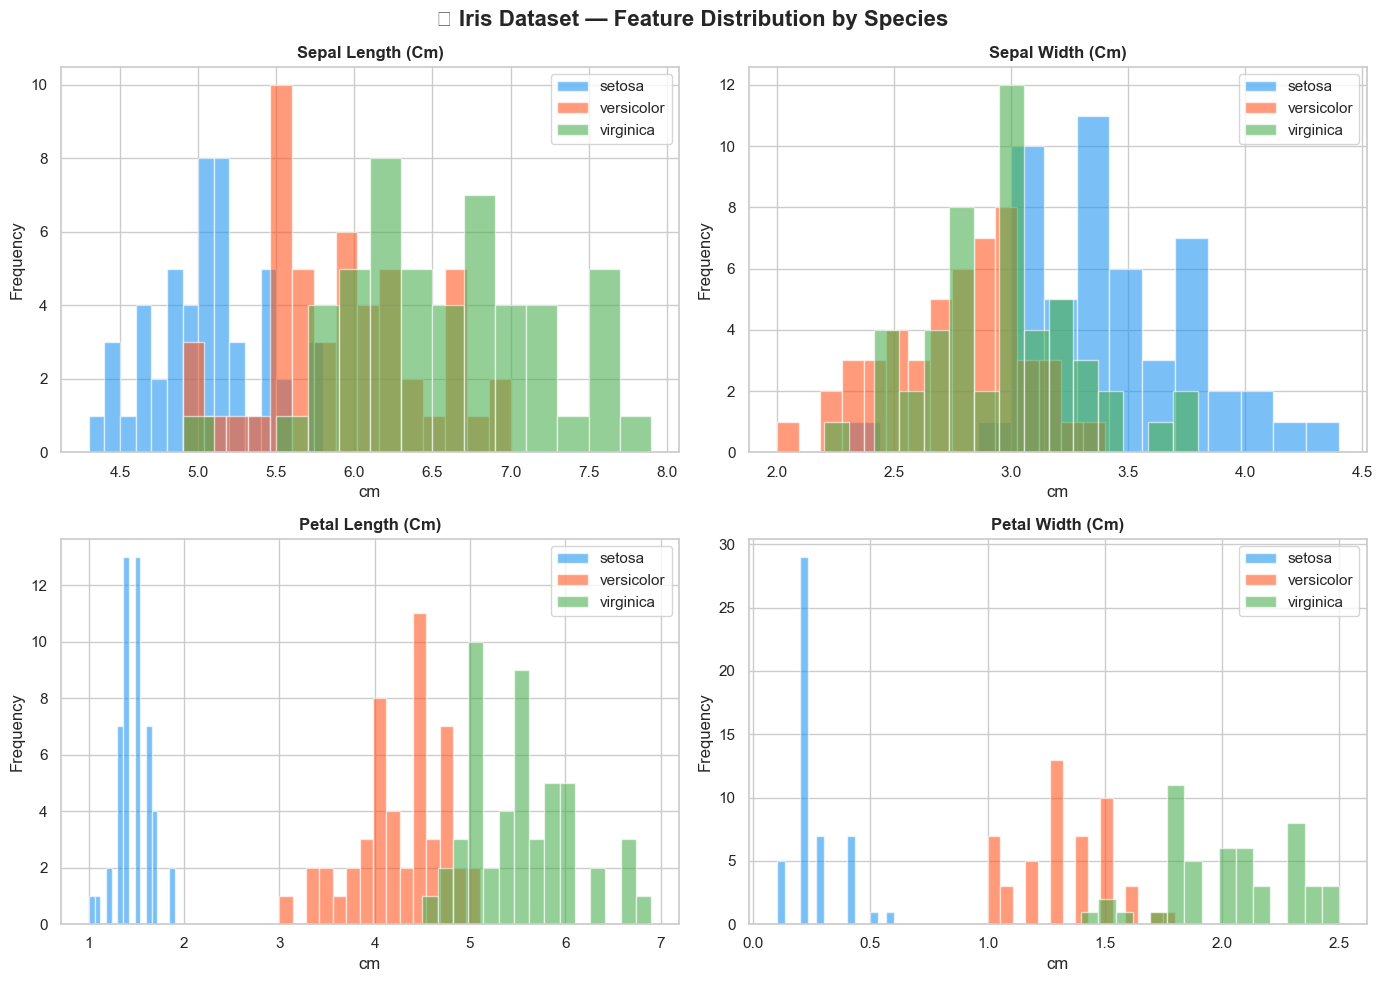

In [22]:
# ─── Exploratory Visualization ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('🌸 Iris Dataset — Feature Distribution by Species', fontsize=16, fontweight='bold')

features = iris.feature_names
colors   = ['#2196F3', '#FF5722', '#4CAF50']

for ax, feature in zip(axes.flatten(), features):
    for i, (species, color) in enumerate(zip(iris.target_names, colors)):
        subset = df[df['species'] == species][feature]
        ax.hist(subset, bins=15, alpha=0.6, color=color, label=species, edgecolor='white')
    ax.set_title(feature.title(), fontsize=12, fontweight='bold')
    ax.set_xlabel('cm')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

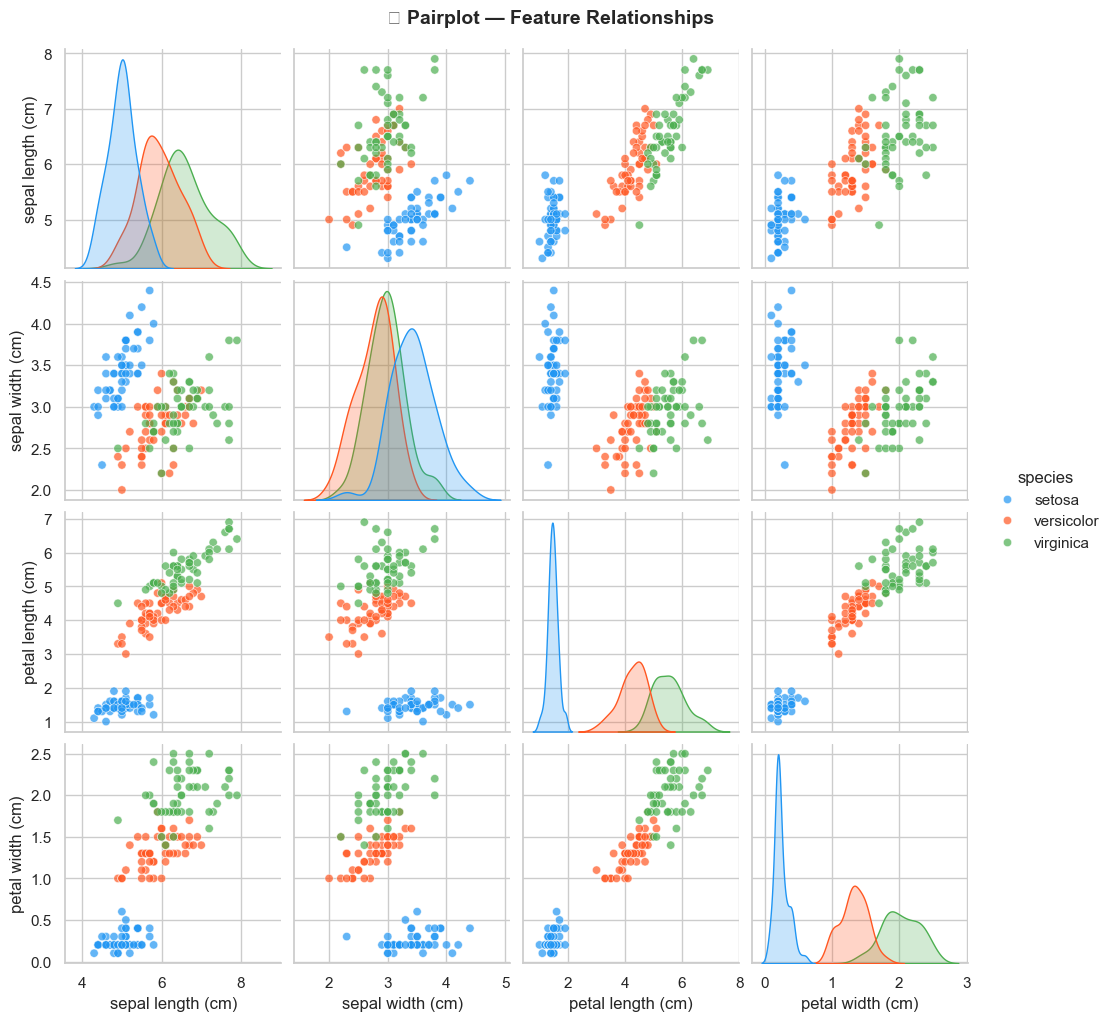

In [23]:
# ─── Pairplot: See All Feature Relationships ──────────────────────
sns.pairplot(
    df.drop(columns=['target']),
    hue='species',
    palette={'setosa': '#2196F3', 'versicolor': '#FF5722', 'virginica': '#4CAF50'},
    diag_kind='kde',
    plot_kws={'alpha': 0.7}
)
plt.suptitle('🔍 Pairplot — Feature Relationships', y=1.02, fontsize=14, fontweight='bold')
plt.show()

---
## ⚙️ Step 3: Feature Engineering — The Gatekeeper Rule (Scaling)

> **Why scale?** KNN uses distance to find neighbors. Without scaling, features with larger ranges (e.g., 0–1000) dominate those with smaller ranges (e.g., 0–1), creating **biased** distance calculations.
>
> `StandardScaler` transforms each feature to **Mean = 0, Variance = 1**.

In [24]:
# ─── Separate Features (X) and Labels (y) ────────────────────────
X = iris.data    # shape: (150, 4)
y = iris.target  # shape: (150,)

print('Feature matrix X shape:', X.shape)
print('Label vector y shape  :', y.shape)
print()
print('Before Scaling — First 3 rows:')
print(X[:3])

Feature matrix X shape: (150, 4)
Label vector y shape  : (150,)

Before Scaling — First 3 rows:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]


---
## ✂️ Step 4: Train-Test Split — Structural Integrity

> **Rule:** Split data **before** scaling to prevent **data leakage** (the test set must remain unseen during training).
>
> - **Training Set (80%):** Pattern Recognition
> - **Test Set (20%):** Validation — locked away until final evaluation
> - **Shuffle = True:** Randomizes to remove order bias

In [25]:
# ─── Train-Test Split (80% / 20%) ────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% reserved for testing
    random_state=42,    # Seed for reproducibility
    shuffle=True        # Removes order bias
)

print('📦 Data Split Summary:')
print(f'   Total samples   : {len(X)}')
print(f'   Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)')
print(f'   Testing  samples: {len(X_test)}  ({len(X_test)/len(X)*100:.0f}%)')

📦 Data Split Summary:
   Total samples   : 150
   Training samples: 120 (80%)
   Testing  samples: 30  (20%)


In [26]:
# ─── Apply Feature Scaling AFTER the Split ───────────────────────
# IMPORTANT: Fit scaler on TRAINING data only, then transform both sets

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # Fit + Transform training data
X_test  = scaler.transform(X_test)        # Transform test data using training stats

print('After Scaling — First 3 training rows:')
print(X_train[:3].round(3))
print()
print(f'Mean (should be ≈ 0): {X_train.mean(axis=0).round(4)}')
print(f'Std  (should be ≈ 1): {X_train.std(axis=0).round(4)}')

After Scaling — First 3 training rows:
[[-1.474  1.204 -1.563 -1.313]
 [-0.133  2.992 -1.276 -1.046]
 [ 1.086  0.086  0.386  0.289]]

Mean (should be ≈ 0): [ 0. -0. -0. -0.]
Std  (should be ≈ 1): [1. 1. 1. 1.]


---
## 🔍 Step 5: Find the Optimal K — The Elbow Method

> - **K=1:** Overfitting — memorizes noise
> - **K=100:** Underfitting — too generic
> - **Optimal K:** The "elbow" — lowest error rate on the validation curve

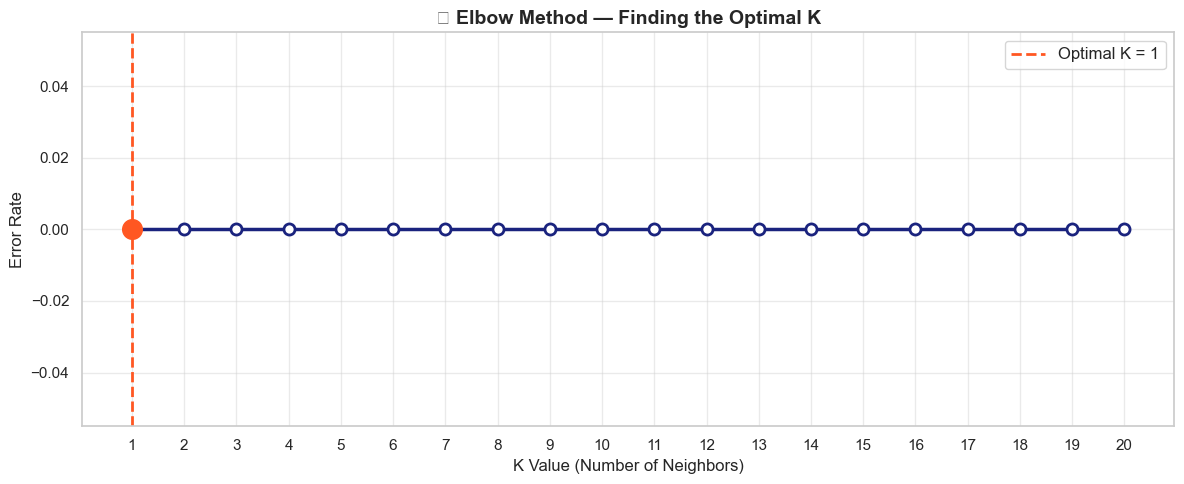

🎯 Optimal K: 1  |  Minimum Error Rate: 0.0000


In [27]:
# ─── Elbow Method: Test K from 1 to 20 ───────────────────────────
error_rates = []
k_range     = range(1, 21)

for k in k_range:
    knn   = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    error = 1 - accuracy_score(y_test, preds)
    error_rates.append(error)

# ─── Plot the Elbow Curve ─────────────────────────────────────────
optimal_k = k_range[error_rates.index(min(error_rates))]

plt.figure(figsize=(12, 5))
plt.plot(k_range, error_rates, 'o-', color='#1A237E', linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
plt.axvline(x=optimal_k, color='#FF5722', linestyle='--', linewidth=2, label=f'Optimal K = {optimal_k}')
plt.scatter([optimal_k], [min(error_rates)], s=200, color='#FF5722', zorder=5)
plt.title('🔧 Elbow Method — Finding the Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('K Value (Number of Neighbors)', fontsize=12)
plt.ylabel('Error Rate', fontsize=12)
plt.xticks(k_range)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f'🎯 Optimal K: {optimal_k}  |  Minimum Error Rate: {min(error_rates):.4f}')

---
## 🤖 Step 6: Train the KNN Model — The Scikit-Learn Workflow

Three-step pattern:
1. **INSTANTIATE** — Build the frame
2. **FIT** — Memorize the training map
3. **PREDICT** — Apply logic to new data

In [28]:
# ─── STEP 1: INSTANTIATE ─────────────────────────────────────────
model = KNeighborsClassifier(n_neighbors=optimal_k)

# ─── STEP 2: FIT (Train on training data) ────────────────────────
model.fit(X_train, y_train)

# ─── STEP 3: PREDICT (Run on unseen test data) ───────────────────
y_pred = model.predict(X_test)

print(f'✅ Model trained with K = {optimal_k}')
print()
print('Sample Predictions vs Actual:')
results = pd.DataFrame({
    'Actual'   : [iris.target_names[i] for i in y_test[:10]],
    'Predicted': [iris.target_names[i] for i in y_pred[:10]],
    'Correct?' : ['✅' if a == p else '❌' for a, p in zip(y_test[:10], y_pred[:10])]
})
print(results.to_string(index=False))

✅ Model trained with K = 1

Sample Predictions vs Actual:
    Actual  Predicted Correct?
versicolor versicolor        ✅
    setosa     setosa        ✅
 virginica  virginica        ✅
versicolor versicolor        ✅
versicolor versicolor        ✅
    setosa     setosa        ✅
versicolor versicolor        ✅
 virginica  virginica        ✅
versicolor versicolor        ✅
versicolor versicolor        ✅


---
## 📊 Step 7: Output Validation — Evaluation Metrics

> ⚠️ **The Accuracy Mirage:** In imbalanced datasets, accuracy alone is misleading.
> We must look deeper using the **Confusion Matrix** and **F1 Score**.

In [29]:
# ─── Accuracy Score ───────────────────────────────────────────────
accuracy = accuracy_score(y_test, y_pred)
f1       = f1_score(y_test, y_pred, average='weighted')

print('=' * 45)
print('         📈 MODEL PERFORMANCE REPORT')
print('=' * 45)
print(f'  Accuracy Score : {accuracy * 100:.2f}%')
print(f'  F1 Score       : {f1:.4f}')
print('=' * 45)

         📈 MODEL PERFORMANCE REPORT
  Accuracy Score : 100.00%
  F1 Score       : 1.0000


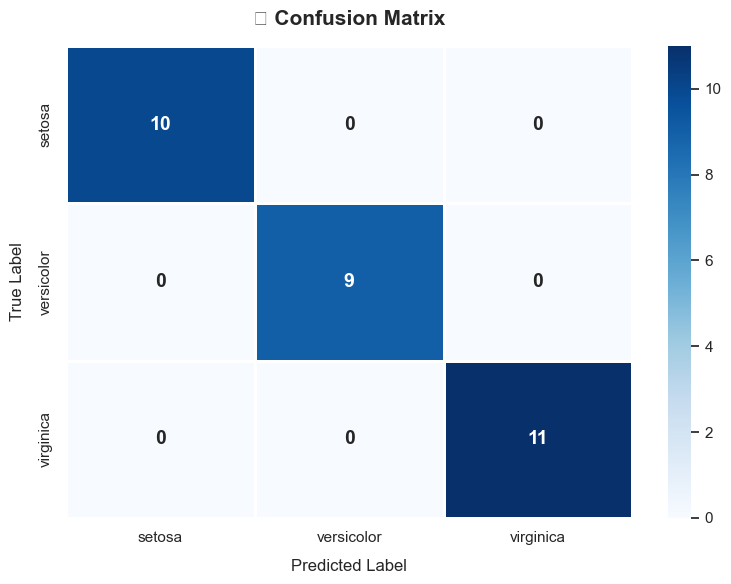


Confusion Matrix Breakdown:
  Rows = Actual class   |   Columns = Predicted class
  Diagonal = Correct predictions (TP / TN)
  Off-diagonal = Errors (FP = False Alarm | FN = Missed Detection)


In [30]:
# ─── Confusion Matrix Heatmap ────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    linewidths=1,
    linecolor='white',
    annot_kws={'size': 14, 'weight': 'bold'}
)
plt.title('🔬 Confusion Matrix', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.ylabel('True Label', fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()

print('\nConfusion Matrix Breakdown:')
print('  Rows = Actual class   |   Columns = Predicted class')
print('  Diagonal = Correct predictions (TP / TN)')
print('  Off-diagonal = Errors (FP = False Alarm | FN = Missed Detection)')

In [31]:
# ─── Full Classification Report ──────────────────────────────────
print('📋 Detailed Classification Report:')
print()
print(classification_report(
    y_test, y_pred,
    target_names=iris.target_names
))

📋 Detailed Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



---
## 🎯 Step 8: Predict a New Sample
Test the trained model on a completely new, unseen flower measurement.

In [32]:
# ─── Predict a Brand-New Sample ──────────────────────────────────
# Format: [sepal_length, sepal_width, petal_length, petal_width] in cm

new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])   # Try changing these values!

# Scale using the SAME scaler fitted on training data
new_flower_scaled = scaler.transform(new_flower)

# Predict
prediction      = model.predict(new_flower_scaled)
prediction_prob = model.predict_proba(new_flower_scaled)

print('🌸 New Flower Measurements (cm):')
print(f'   Sepal Length : {new_flower[0][0]}')
print(f'   Sepal Width  : {new_flower[0][1]}')
print(f'   Petal Length : {new_flower[0][2]}')
print(f'   Petal Width  : {new_flower[0][3]}')
print()
print(f'🤖 Predicted Species: {iris.target_names[prediction[0]].upper()}')
print()
print('📊 Prediction Probabilities:')
for species, prob in zip(iris.target_names, prediction_prob[0]):
    bar = '█' * int(prob * 30)
    print(f'   {species:12s}: {bar:<30} {prob*100:.1f}%')

🌸 New Flower Measurements (cm):
   Sepal Length : 5.1
   Sepal Width  : 3.5
   Petal Length : 1.4
   Petal Width  : 0.2

🤖 Predicted Species: SETOSA

📊 Prediction Probabilities:
   setosa      : ██████████████████████████████ 100.0%
   versicolor  :                                0.0%
   virginica   :                                0.0%


---
## 🚀 Step 9 (Bonus): Compare Multiple Algorithms
Go beyond KNN — compare it against other classifiers to see which performs best.

In [33]:
from sklearn.tree          import DecisionTreeClassifier
from sklearn.svm           import SVC
from sklearn.naive_bayes   import GaussianNB
from sklearn.ensemble      import RandomForestClassifier
from sklearn.linear_model  import LogisticRegression

# ─── Define Classifiers to Compare ───────────────────────────────
classifiers = {
    'KNN (Optimal K)':       KNeighborsClassifier(n_neighbors=optimal_k),
    'Decision Tree':         DecisionTreeClassifier(random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF Kernel)':      SVC(kernel='rbf', random_state=42),
    'Naive Bayes':           GaussianNB(),
    'Logistic Regression':   LogisticRegression(max_iter=200, random_state=42),
}

# ─── Train & Evaluate Each ───────────────────────────────────────
comparison_results = []

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    preds    = clf.predict(X_test)
    acc      = accuracy_score(y_test, preds)
    f1_score_val = f1_score(y_test, preds, average='weighted')
    comparison_results.append({'Algorithm': name, 'Accuracy': acc, 'F1 Score': f1_score_val})

results_df = pd.DataFrame(comparison_results).sort_values('F1 Score', ascending=False)
results_df['Accuracy'] = results_df['Accuracy'].map('{:.2%}'.format)
results_df['F1 Score'] = results_df['F1 Score'].map('{:.4f}'.format)
results_df.index = range(1, len(results_df) + 1)

print('🏆 Algorithm Comparison Leaderboard:')
print(results_df.to_string())

🏆 Algorithm Comparison Leaderboard:
             Algorithm Accuracy F1 Score
1      KNN (Optimal K)  100.00%   1.0000
2        Decision Tree  100.00%   1.0000
3        Random Forest  100.00%   1.0000
4     SVM (RBF Kernel)  100.00%   1.0000
5          Naive Bayes  100.00%   1.0000
6  Logistic Regression  100.00%   1.0000


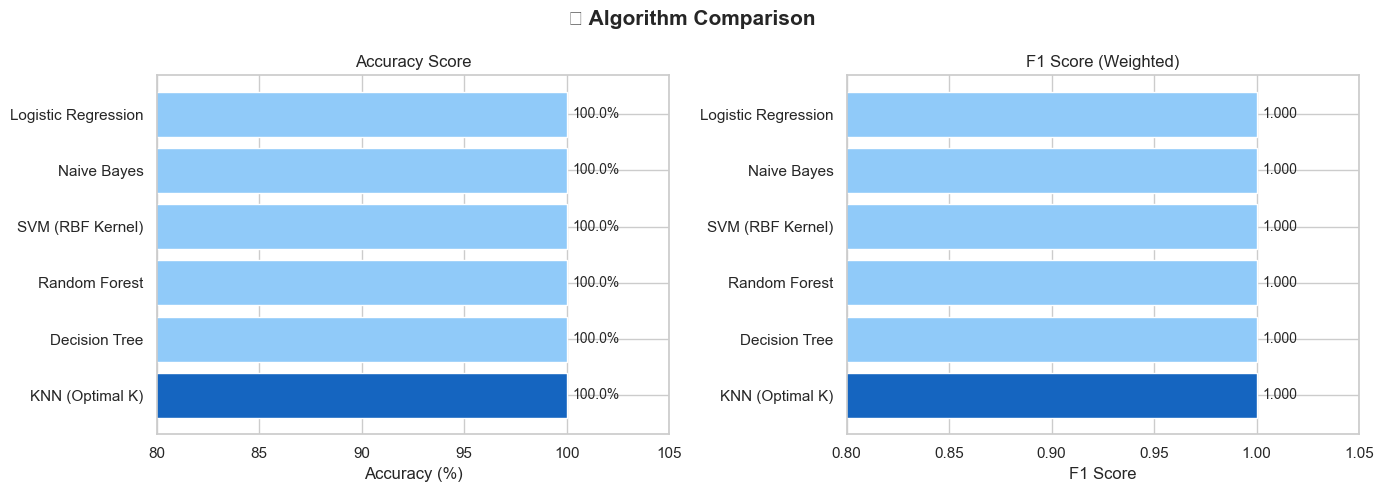

In [34]:
# ─── Bar Chart Comparison ─────────────────────────────────────────
comp_plot = pd.DataFrame(comparison_results).sort_values('F1 Score')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🏆 Algorithm Comparison', fontsize=15, fontweight='bold')

colors_bar = ['#90CAF9' if name != 'KNN (Optimal K)' else '#1565C0'
              for name in comp_plot['Algorithm']]

ax1.barh(comp_plot['Algorithm'], comp_plot['Accuracy'] * 100, color=colors_bar, edgecolor='white')
ax1.set_xlabel('Accuracy (%)')
ax1.set_title('Accuracy Score')
ax1.set_xlim(80, 105)
for bar, val in zip(ax1.patches, comp_plot['Accuracy']):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val*100:.1f}%', va='center', fontsize=10)

ax2.barh(comp_plot['Algorithm'], comp_plot['F1 Score'], color=colors_bar, edgecolor='white')
ax2.set_xlabel('F1 Score')
ax2.set_title('F1 Score (Weighted)')
ax2.set_xlim(0.8, 1.05)
for bar, val in zip(ax2.patches, comp_plot['F1 Score']):
    ax2.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## 📌 Project Summary

| Step | Action | Tool Used |
|------|--------|-----------|
| 1 | Load & Explore Dataset | `sklearn.datasets.load_iris` |
| 2 | Split Data | `train_test_split` (80/20, shuffled) |
| 3 | Scale Features | `StandardScaler` (Mean=0, Var=1) |
| 4 | Find Optimal K | Elbow Method (error rate plot) |
| 5 | Train Model | `KNeighborsClassifier.fit()` |
| 6 | Predict | `model.predict()` |
| 7 | Evaluate | `confusion_matrix`, `f1_score`, `classification_report` |
| 8 | Bonus | Compare 6 different algorithms |

---
### 🎓 Key Concepts Learned
- **Supervised Learning:** Provide labeled history → machine derives the logic
- **Feature Scaling:** Mandatory for distance-based algorithms like KNN
- **Train/Test Split:** Prevents data leakage; shuffle removes order bias  
- **KNN:** The Proximity Principle — similar things exist in close proximity
- **Confusion Matrix:** TP, FP (False Alarm), FN (Missed Detection), TN
- **F1 Score:** Harmonic mean of Precision & Recall — better than accuracy alone

---
*DecodeLabs Industrial Training Kit | Batch 2026*